
# Hotel Booking Cancellation Prediction using Random Forest
## Random Forest - IT22198686

This notebook focuses **only on Random Forest** for predicting hotel booking cancellations.
It includes:
- dataset loading and understanding
- preprocessing and feature engineering
- Random Forest model building
- hyperparameter tuning
- evaluation using multiple metrics
- feature importance analysis
- critical discussion and future improvements


## 1. Import Libraries

In [ ]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


## 2. Load Dataset

In [ ]:

# Keep hotel_bookings.csv in the same folder as this notebook
DATA_PATH = 'hotel_bookings.csv'

df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
df.head()


Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Dataset Overview

In [ ]:
print('Number of rows   :', df.shape[0])
print('Number of columns:', df.shape[1])
print('Column names:')
print(df.columns.tolist())

print('Target distribution:')
print(df['is_canceled'].value_counts())

print('Target percentages (%):')
print((df['is_canceled'].value_counts(normalize=True) * 100).round(2))

Number of rows   : 119390
Number of columns: 32
Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']
Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64
Target percentages (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


In [ ]:

summary_table = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_values': df.isna().sum().values,
    'missing_percentage': (df.isna().mean() * 100).round(2).values,
    'unique_values': [df[col].nunique() for col in df.columns]
})

summary_table.sort_values(by='missing_percentage', ascending=False)


,column,dtype,missing_values,missing_percentage,unique_values
24,company,float64,112593,94.31,352
23,agent,float64,16340,13.69,333
13,country,object,488,0.41,177
0,hotel,object,0,0.00,2
4,arrival_date_month,object,0,0.00,12
5,arrival_date_week_number,int64,0,0.00,53
2,lead_time,int64,0,0.00,479
1,is_canceled,int64,0,0.00,2
7,stays_in_weekend_nights,int64,0,0.00,17
8,stays_in_week_nights,int64,0,0.00,35


## 4. Exploratory Data Analysis

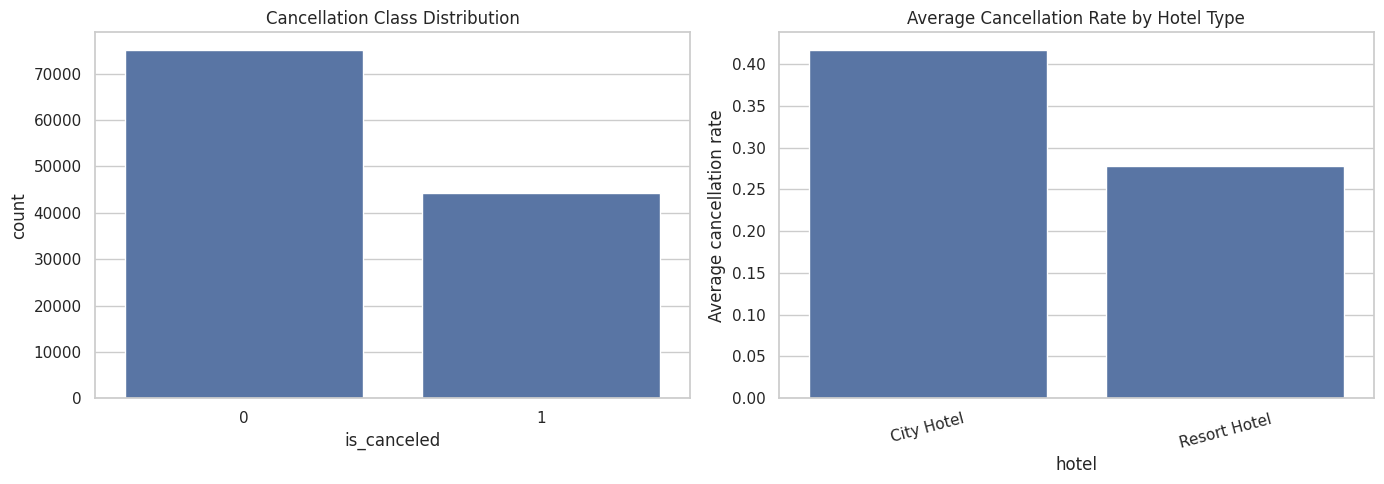

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='is_canceled', ax=axes[0])
axes[0].set_title('Cancellation Class Distribution')
axes[0].set_xlabel('is_canceled')

cancel_rate_by_hotel = df.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)
sns.barplot(x=cancel_rate_by_hotel.index, y=cancel_rate_by_hotel.values, ax=axes[1])
axes[1].set_title('Average Cancellation Rate by Hotel Type')
axes[1].set_ylabel('Average cancellation rate')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


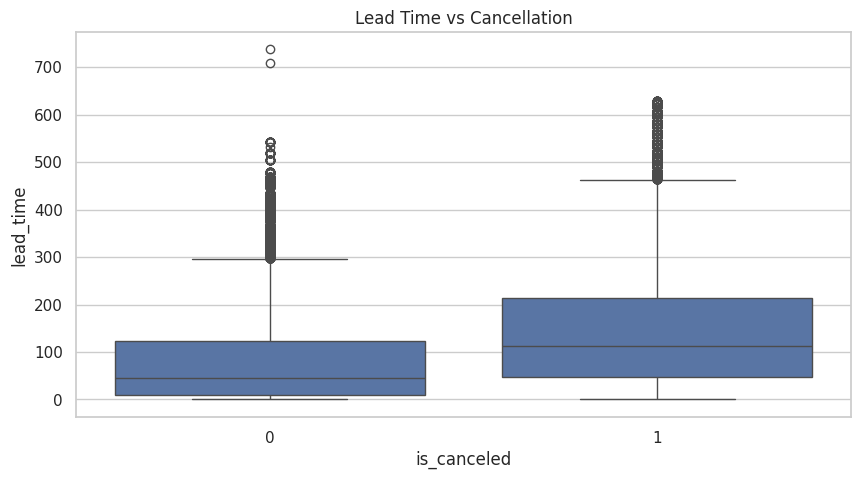

In [ ]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title('Lead Time vs Cancellation')
plt.show()


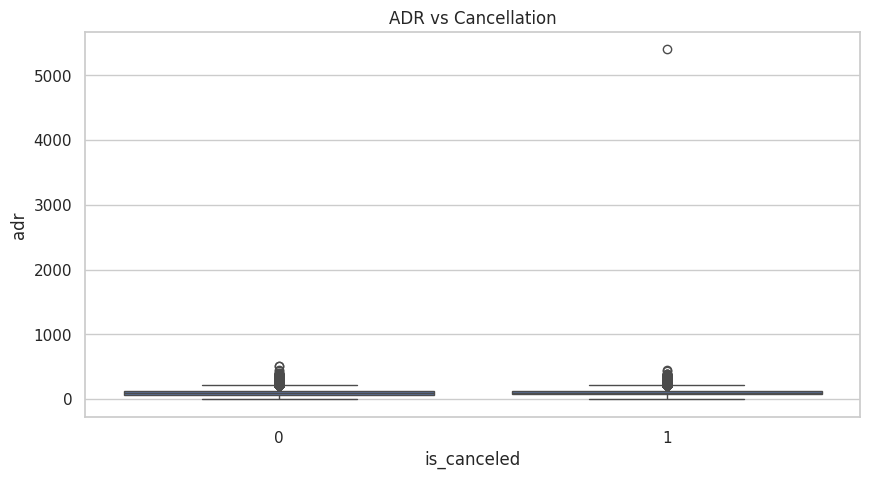

In [ ]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_canceled', y='adr')
plt.title('ADR vs Cancellation')
plt.show()



## 5. Data Preprocessing and Feature Engineering

Key preprocessing decisions:
- remove features that leak the target (`reservation_status`, `reservation_status_date`)
- drop `company` because it has too many missing values
- keep `agent` and let the pipeline impute missing values
- create helpful features such as total guests and total stay
- use one-hot encoding for categorical variables
- use a stratified train/test split to preserve class proportions


In [ ]:

model_df = df.copy()

# Remove target leakage columns
leakage_columns = ['reservation_status', 'reservation_status_date']
model_df = model_df.drop(columns=leakage_columns)

# Drop column with very high missingness
model_df = model_df.drop(columns=['company'])

# Fill rare missing value in children before feature engineering
model_df['children'] = model_df['children'].fillna(0)

# Feature engineering
model_df['total_guests'] = model_df['adults'] + model_df['children'] + model_df['babies']
model_df['total_nights'] = model_df['stays_in_weekend_nights'] + model_df['stays_in_week_nights']
model_df['booking_changes_per_night'] = model_df['booking_changes'] / (model_df['total_nights'] + 1)

print('Updated shape after preprocessing steps:', model_df.shape)
model_df.head()


Updated shape after preprocessing steps: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,booking_changes_per_night
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,0,Transient,0.0,0,0,2.0,0,3.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,0,Transient,0.0,0,0,2.0,0,4.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,0,Transient,75.0,0,0,1.0,1,0.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0,Transient,75.0,0,0,1.0,1,0.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0,Transient,98.0,0,1,2.0,2,0.0


In [ ]:
# Define features and target
X = model_df.drop('is_canceled', axis=1)
y = model_df['is_canceled']

In [ ]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical feature count:', len(categorical_features))
print('Numerical feature count  :', len(numerical_features))
print('Categorical columns:')
print(categorical_features)

Categorical feature count: 10
Numerical feature count  : 21
Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape :', X_test.shape)


Training set shape: (95512, 31)
Testing set shape : (23878, 31)


In [ ]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])


## 6. Baseline Random Forest Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

baseline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=1,
        class_weight='balanced'
    ))
])

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)
baseline_prob = baseline_rf.predict_proba(X_test)[:, 1]

baseline_results = {
    'Accuracy': accuracy_score(y_test, baseline_pred),
    'Precision': precision_score(y_test, baseline_pred, zero_division=0),
    'Recall': recall_score(y_test, baseline_pred, zero_division=0),
    'F1-Score': f1_score(y_test, baseline_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, baseline_prob)
}

results_df = pd.DataFrame(baseline_results, index=['Baseline Random Forest']).T
print(results_df)
results_df

           Baseline Random Forest
Accuracy                 0.862677
Precision                0.817115
Recall                   0.810741
F1-Score                 0.813915
ROC-AUC                  0.935837


,Baseline Random Forest
Accuracy,0.862677
Precision,0.817115
Recall,0.810741
F1-Score,0.813915
ROC-AUC,0.935837


## 7. Hyperparameter Tuning for Random Forest

In [ ]:
# Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1,   # Safer memory usage
        class_weight='balanced'
    ))
])

# Smaller parameter space (faster)
param_distributions = {
    'model__n_estimators': [50, 100],          # reduced trees
    'model__max_depth': [10, 20],              # remove None (heavy)
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# Reduce folds (faster)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Random search (very fast config)
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=3,              # only 3 combinations
    scoring='f1',
    cv=cv,
    verbose=2,             # shows progress
    random_state=RANDOM_STATE,
    n_jobs=1               # Safer memory usage
)

# Train
random_search.fit(X_train, y_train)

# Results
print('Best parameters:')
print(random_search.best_params_)

print('Best cross-validation F1-score:',
      round(random_search.best_score_, 4))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END model__max_depth=10, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=50; total time=   5.7s
[CV] END model__max_depth=10, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=50; total time=   6.2s
[CV] END model__max_depth=10, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=50; total time=   5.7s
[CV] END model__max_depth=10, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  11.2s
[CV] END model__max_depth=10, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  10.8s
[CV] END model__max_depth=10, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  11.3s
[CV] END model__max_depth=10, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time=  10.5s
[CV] END model__max_depth=10, model__min_

In [ ]:

best_rf = random_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

final_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline Random Forest': [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred),
        roc_auc_score(y_test, baseline_prob)
    ],
    'Tuned Random Forest': [
        accuracy_score(y_test, best_rf_pred),
        precision_score(y_test, best_rf_pred),
        recall_score(y_test, best_rf_pred),
        f1_score(y_test, best_rf_pred),
        roc_auc_score(y_test, best_rf_prob)
    ]
})

final_results


,Metric,Baseline Random Forest,Tuned Random Forest
0,Accuracy,0.862677,0.849946
1,Precision,0.817115,0.807863
2,Recall,0.810741,0.780554
3,F1-Score,0.813915,0.793974
4,ROC-AUC,0.935837,0.921926


## 8. Detailed Evaluation of the Tuned Random Forest

In [ ]:
print('Classification Report for Tuned Random Forest\n')
print(classification_report(y_test, best_rf_pred))

Classification Report for Tuned Random Forest

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     15033
           1       0.81      0.78      0.79      8845

    accuracy                           0.85     23878
   macro avg       0.84      0.84      0.84     23878
weighted avg       0.85      0.85      0.85     23878



<Figure size 600x500 with 0 Axes>

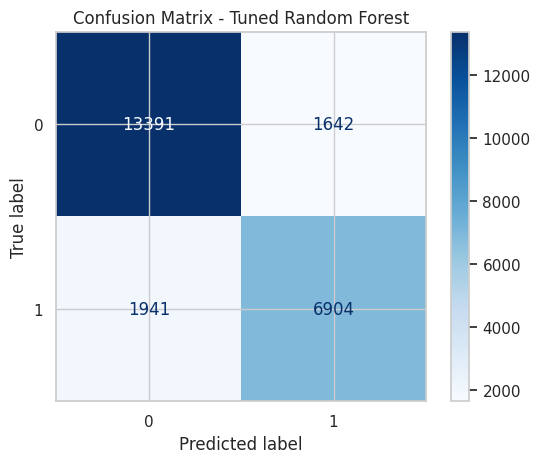

In [ ]:

cm = confusion_matrix(y_test, best_rf_pred)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()


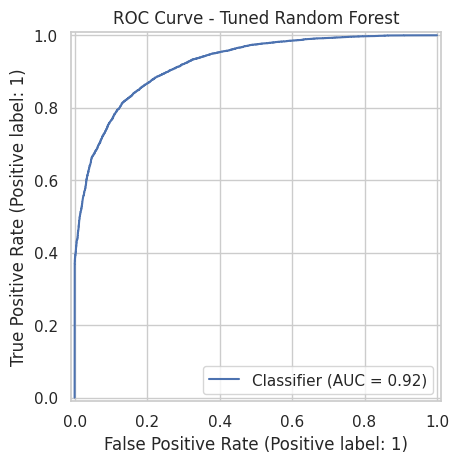

In [ ]:

RocCurveDisplay.from_predictions(y_test, best_rf_prob)
plt.title('ROC Curve - Tuned Random Forest')
plt.show()


## 9. Cross-Validation Performance

In [ ]:

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)

print('Cross-validation F1 scores:', np.round(cv_scores, 4))
print('Mean CV F1-score:', round(cv_scores.mean(), 4))
print('Standard deviation:', round(cv_scores.std(), 4))


Cross-validation F1 scores: [0.789  0.7837 0.7915]
Mean CV F1-score: 0.7881
Standard deviation: 0.0032
